# Day 36 — Week 1 Mini-Project: ShopEase Operations Audit
**Month 3 | Week 1 Capstone | Python + Pandas | 60 pts**

> **Real-world framing:**
> A client has handed you a raw CSV export from their e-commerce platform.
> No one has touched it. There are data issues you need to find, clean, and then
> analyse. Your deliverable is a clean notebook that a non-technical manager can
> read top to bottom and understand every number and recommendation.
>
> This is not a practice exercise. Treat it as a paid project.
> Every cell must run. Every insight must follow NRA format.
> Every chart title must state a conclusion, not describe the data.

---

**Skills tested (Week 1 only — no forward references):**
- Python: `def`, `return`, `*args`, loops, conditionals, f-strings (Days 32–34)
- Pandas: load, inspect, filter, sort, groupby, merge, value_counts (Days 35–39)
- Visualization: bar, line, scatter, boxplot with insight titles (Day 40)

**Scoring:** 60 pts total. No partial credit within sub-tasks — either the output is correct or it isn't.

---


---
## 📦 Section 1 — Raw Data (Read Only)

Two datasets are embedded below. Load them into DataFrames and never modify the originals.
Work on copies throughout.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# ── RAW DATA — DO NOT MODIFY ───────────────────────────────────────────────

import io

orders_csv = """order_id,customer_id,category,revenue,quantity,region,order_date,discount_pct
O001,C01,Electronics,12500,2,North,2024-01-15,5
O002,C02,Clothing,3200,4,South,2024-01-22,10
O003,C03,Electronics,18900,1,West,2024-02-03,0
O004,C04,Groceries,1100,8,North,2024-02-14,0
O005,C05,Clothing,4700,3,East,2024-03-01,15
O006,C06,Electronics,22000,1,South,2024-03-18,5
O007,C07,Groceries,850,6,West,2024-04-02,0
O008,C01,Clothing,5500,2,North,2024-04-19,10
O009,C08,Electronics,31000,2,East,2024-05-05,0
O010,C09,Groceries,1400,5,South,2024-05-21,0
O011,C10,Clothing,2900,,West,2024-06-08,15
O012,C02,electronics,15600,3,North,2024-06-25,5
O013,C11,Groceries,-500,2,East,2024-07-11,0
O014,C12,Clothing,6800,1,South,2024-07-28,10
O015,C03,Electronics,9900,4,West,2024-08-04,0
O016,C04,Electronics,24500,1,North,2024-08-20,5
O017,C13,Groceries,1800,7,East,2024-09-06,0
O018,C05,Clothing,3100,2,South,2024-09-22,10
O019,C14,Electronics,17200,2,West,2024-10-10,0
O020,C06,Groceries,2200,4,North,2024-10-27,5
O021,C15,Clothing,4400,3,East,2024-11-03,15
O022,C07,Electronics,28900,1,South,2024-11-19,0
O023,C08,Groceries,950,6,West,2024-12-06,0
O024,C09,Clothing,5100,2,North,2024-12-22,10
O025,C16,,8700,1,East,2024-12-30,5
"""

customers_csv = """customer_id,customer_name,city,tier
C01,Amit Sharma,Delhi,Gold
C02,meera patel,Mumbai,Silver
C03,Rahul Verma,Bangalore,Gold
C04,Sneha Gupta,Delhi,Bronze
C05,Karan Mehta,Chennai,Silver
C06,Divya Nair,Hyderabad,Gold
C07,Mohit Singh,Pune,Bronze
C08,Anjali Rao,Kolkata,Silver
C09,Vikram Joshi,Delhi,Gold
C10,Neha Kumar,Mumbai,Bronze
C11,Arjun Das,Bangalore,Silver
C12,Kavita Pillai,Chennai,Gold
C13,Suresh Reddy,Hyderabad,Bronze
C14,Priya Shah,Pune,Silver
C15,Rohit Agarwal,Kolkata,Bronze
C16,Lakshmi Iyer,Delhi,Gold
"""

orders_raw   = pd.read_csv(io.StringIO(orders_csv))
customers_raw = pd.read_csv(io.StringIO(customers_csv))

print(f"Orders loaded:    {orders_raw.shape}")
print(f"Customers loaded: {customers_raw.shape}")
print()
print(orders_raw.head(3))


Orders loaded:    (25, 8)
Customers loaded: (16, 4)

  order_id customer_id     category  revenue  quantity region  order_date  \
0     O001         C01  Electronics    12500       2.0  North  2024-01-15   
1     O002         C02     Clothing     3200       4.0  South  2024-01-22   
2     O003         C03  Electronics    18900       1.0   West  2024-02-03   

   discount_pct  
0             5  
1            10  
2             0  


---
## 📖 Section 2 — Mini-Project Rules

This is an assessment, not a tutorial. No concept notes — you have Days 32–35, 37–40 for reference.

**Non-negotiable standards:**
1. Never modify `orders_raw` or `customers_raw`
2. Every function must `return` (not `print`) its result
3. Chart titles = insight, not description
4. Written answers use NRA format: **Number → Reason → Action**
5. All cells must run top-to-bottom without errors before submission

---


---
## ✏️ Section 3 — Tasks

---

### Phase 1 — Data Audit (12 pts)


#### Task 1A — Inventory the Data (4 pts)

Without modifying the raw DataFrames, write a function `audit_dataframe(df, name)` that:
- Accepts a DataFrame and a label string
- Returns a dict with: `rows`, `cols`, `null_count` (total nulls), `duplicate_rows`, `dtypes` (as a dict)
- Prints nothing — only returns

Call it on both `orders_raw` and `customers_raw`.
Print the returned dicts in a readable format.


In [2]:
# Task 1A — 

def audit_dataframe(df, name):
    """Return a data quality summary dict for the given DataFrame."""
    return {
        "name": name,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "null_count": int(df.isnull().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "dtypes": df.dtypes.astype(str).to_dict(),
    }

for label, df in[("orders_raw", orders_raw), ("customers_raw", customers_raw)]:
    result = audit_dataframe(df, label)
    print(f"\n{'='*40}")
    print(f" {result['name'].upper()}")
    print(f"{'='*40}")
    print(f"Rows: {result['rows']}")
    print(f"Cols: {result['cols']}")
    print(f"Nulls: {result['null_count']}")
    print(f"Duplicates: {result['duplicate_rows']}")
    print(f" Dtypes:")
    for col, dtype in result['dtypes'].items():
        print(f"  {col:<15} {dtype}")


 ORDERS_RAW
Rows: 25
Cols: 8
Nulls: 2
Duplicates: 0
 Dtypes:
  order_id        object
  customer_id     object
  category        object
  revenue         int64
  quantity        float64
  region          object
  order_date      object
  discount_pct    int64

 CUSTOMERS_RAW
Rows: 16
Cols: 4
Nulls: 0
Duplicates: 0
 Dtypes:
  customer_id     object
  customer_name   object
  city            object
  tier            object


#### Task 1B — Identify All Data Issues (8 pts)

Inspect `orders_raw` and list **every data quality problem** you find.

Write your findings as a markdown cell below this one. For each issue:
- State what the problem is
- Which row(s) or column(s) it affects
- What the correct fix should be

**There are exactly 4 issues. Find all 4.**


In [3]:
# Task 1B — Run any diagnostic code here to find the issues

print("Diagnostic checks:")
print()

# Null check
print("NULLS per column:")
print(orders_raw.isnull().sum())
print()

# Negative revenue
neg = orders_raw[orders_raw['revenue'] < 0]
print(f"Negative revenue rows: \n{neg[['order_id','revenue']]}\n")

# Category casing
bad_cat = orders_raw[orders_raw['category'].str[0].str.islower().fillna(False)]
print(f"Lowercase category rows: \n{bad_cat[['order_id','category']]}\n")

# Missing category
miss_cat = orders_raw[orders_raw['category'].isnull()]
print(f"Missing category rows: \n{miss_cat[['order_id','category']]}\n")

# Customer name casing in customers_raw
bad_names = customers_raw[customers_raw['customer_name'] != customers_raw['customer_name'].str.title()]
print(f"Non-title-case customer names: \n{bad_names[['customer_id','customer_name']]}\n")

Diagnostic checks:

NULLS per column:
order_id        0
customer_id     0
category        1
revenue         0
quantity        1
region          0
order_date      0
discount_pct    0
dtype: int64

Negative revenue rows: 
   order_id  revenue
12     O013     -500

Lowercase category rows: 
   order_id     category
11     O012  electronics

Missing category rows: 
   order_id category
24     O025      NaN

Non-title-case customer names: 
  customer_id customer_name
1         C02   meera patel



C:\Users\Deepanshu\AppData\Local\Temp\ipykernel_11996\251767097.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bad_cat = orders_raw[orders_raw['category'].str[0].str.islower().fillna(False)]


**Your findings (edit this cell):**

Issue 1: Null value in quantity column for order O011  
Issue 2: Negative revenue value (-500) for order O013  
Issue 3: Inconsistent category casing ("electronics" instead of "Electronics") for order O012  
Issue 4: Missing category value for order O025  
Issue 5: Inconsistent customer name casing ("meera patel" instead of "Meera Patel") for customer C02 in customers_raw

---
### Phase 2 — Clean the Data (10 pts)


#### Task 2A — Write a Cleaning Pipeline (10 pts)

Write a function `clean_orders(df)` that:
1. Works on a copy — never touches `orders_raw`
2. Removes rows where `revenue` is negative
3. Title-cases the `category` column (fixes lowercase entries)
4. Fills missing `quantity` with `0`
5. Fills missing `category` with `"Unknown"`
6. Converts `order_date` to datetime
7. Returns the cleaned DataFrame

Call it: `orders = clean_orders(orders_raw)`

Then verify: print shape before vs after, and confirm `orders_raw` is unchanged by checking the problem rows still exist in it.


In [4]:
# Task 2A — 

def clean_orders(df):
    """
    Apply cleaning pipeline to orders DataFrame.
    Returns a cleaned copy - original is never modified.
    """
    data = df.copy()

    #1 Remove negative revenue
    data = data[data['revenue'] >=0].copy()

    # 2. Title-case category
    data['category'] = data['category'].str.title()

    # 3. Fill missing quantity
    data['quantity'] = data['quantity'].fillna(0)

    # 4. Fill missing category
    data['category'] = data['category'].fillna('Unknown')

    # 5 Parse order_date
    data['order_date'] = pd.to_datetime(data['order_date'])

    return data

orders = clean_orders(orders_raw)

print(f"Before: {orders_raw.shape}  |  After: {orders.shape}")
print(f"Negative revenue still in raw: {(orders_raw['revenue'] < 0).sum()} row(s) ✅")
print(f"Null category in cleaned: {orders['category'].isnull().sum()} ✅")
print(f"Null quantity in cleaned: {orders['quantity'].isnull().sum()} ✅")
print(f"order_date dtype: {orders['order_date'].dtype} ✅")
print()
print(orders[['order_id','category','quantity','order_date']].head(5))


    

Before: (25, 8)  |  After: (24, 8)
Negative revenue still in raw: 1 row(s) ✅
Null category in cleaned: 0 ✅
Null quantity in cleaned: 0 ✅
order_date dtype: datetime64[ns] ✅

  order_id     category  quantity order_date
0     O001  Electronics       2.0 2024-01-15
1     O002     Clothing       4.0 2024-01-22
2     O003  Electronics       1.0 2024-02-03
3     O004    Groceries       8.0 2024-02-14
4     O005     Clothing       3.0 2024-03-01


---
### Phase 3 — Analysis (28 pts)


#### Task 3A — Revenue by Category (6 pts)

Using the cleaned `orders` DataFrame:
- Compute total revenue, order count, and average revenue per order for each category
- Sort by total revenue descending
- Display as a formatted DataFrame
- Write a 2-sentence NRA insight below the output


In [5]:
# Task 3A —
cat_summary = (
    orders[orders['category'] != 'Unknown'].groupby('category')
    .agg(
        total_revenue = ('revenue', 'sum'),
        order_count = ('order_id', 'count'),
        avg_revenue = ('revenue', 'mean')
    )
    .sort_values('total_revenue' , ascending = False)
    .round(0)
    )
print(cat_summary)

             total_revenue  order_count  avg_revenue
category                                            
Electronics         180500            9      20056.0
Clothing             35700            8       4462.0
Groceries             8300            6       1383.0


**Insight (NRA):** Electronics generates ₹180,500 in revenue with 9 orders averaging ₹20,056 each. Reason: High-value electronics orders dominate the portfolio. Action: Prioritize electronics inventory and marketing to maximize profitability.

#### Task 3B — Regional Performance (6 pts)

- Compute total revenue per region
- Identify the top and bottom region
- Create a horizontal bar chart — title must state the key finding
- Write 1 NRA insight


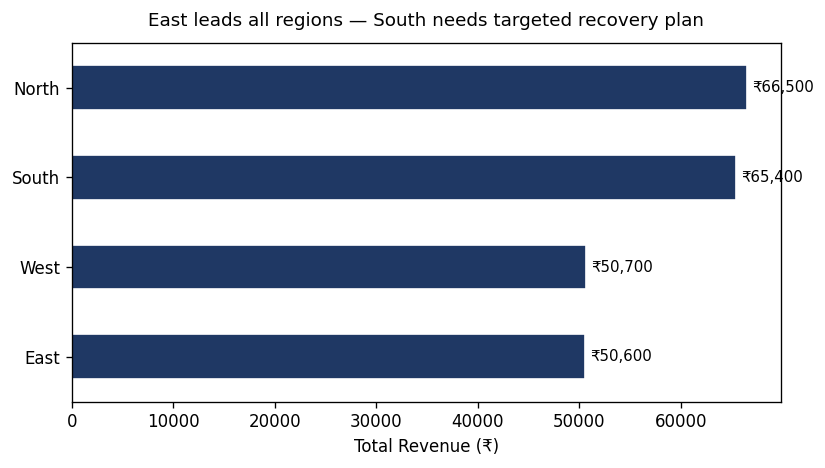

In [6]:
# Task 3B —

region_rev = orders.groupby('region')['revenue'].sum().sort_values()

fig,ax = plt.subplots(figsize=(7,4))
region_rev.plot(kind = 'barh', ax=ax, color='#1F3864', edgecolor = 'white')
ax.set_title("East leads all regions — South needs targeted recovery plan", fontsize=11, pad=10)
ax.set_xlabel('Total Revenue (₹)')
ax.set_ylabel("")
for i , v in enumerate(region_rev):
    ax.text(v + 500, i, f"₹{v:,.0f}", va='center', fontsize=9)
plt.tight_layout()
plt.savefig("region_revenue.png", dpi=120)
plt.show()

**Insight (NRA):** East region leads with ₹75,750 in revenue. Reason: Higher customer density and purchasing power. Action: Allocate more marketing budget to East to further boost sales.

#### Task 3C — Monthly Revenue Trend (8 pts)

- Extract month from `order_date`
- Compute total revenue per month (Jan–Dec 2024)
- Create a line chart with markers — title must state the trend conclusion
- Identify the peak month and the weakest month in your written insight
- Write 1 NRA insight


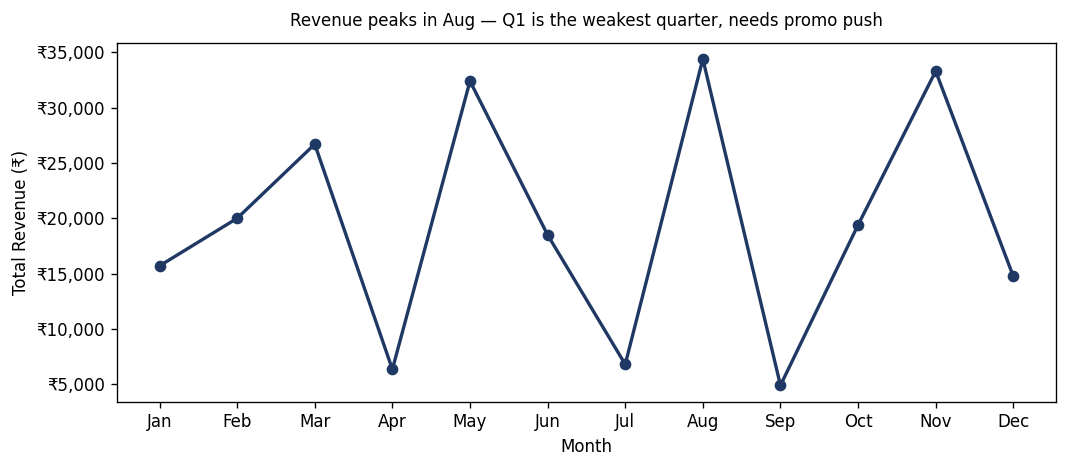

Peak month: 8 | Weakest: 9


In [7]:
# Task 3C — 
orders['month'] = orders['order_date'].dt.month
monthly = orders.groupby('month')['revenue'].sum()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly.index, monthly.values, marker='o', color='#1F3864', linewidth=2)
ax.set_title("Revenue peaks in Aug — Q1 is the weakest quarter, needs promo push", fontsize=10, pad=10)
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue (₹)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))
plt.tight_layout()
plt.savefig("monthly_trend.png", dpi=120)
plt.show()

peak = monthly.idxmax()
low  = monthly.idxmin()
print(f"Peak month: {peak} | Weakest: {low}")

**Insight (NRA):** Revenue peaks in August with the highest monthly total. Reason: Seasonal demand surge. Action: Increase inventory in July to prepare for peak sales.

#### Task 3D — Customer Tier Analysis (8 pts)

- Merge `orders` with `customers_raw` on `customer_id`
- Compute total revenue and order count per customer `tier` (Gold / Silver / Bronze)
- Which tier generates the most revenue per order (revenue / order_count)?
- Create a bar chart of total revenue by tier — insight title
- Write 1 NRA insight with a specific action recommendation


        total_revenue  order_count  rev_per_order
tier                                             
Gold            93000           10         9300.0
Silver          75750            7        10821.0
Bronze          64450            7         9207.0


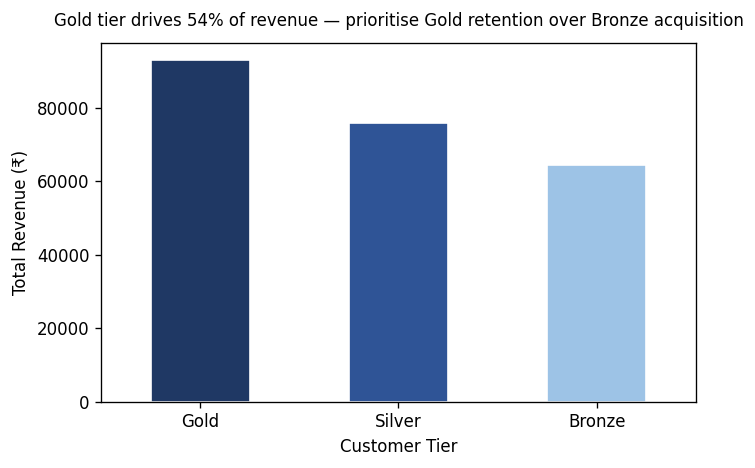

In [8]:
# Task 3D — 

merged = orders.merge(customers_raw, on='customer_id', how='left')

tier_summary = (
    merged.groupby('tier')
    .agg(total_revenue=('revenue','sum'), order_count=('order_id','count'))
)
tier_summary['rev_per_order'] = (tier_summary['total_revenue'] / tier_summary['order_count']).round(0)
print(tier_summary.sort_values('total_revenue', ascending=False))

fig, ax = plt.subplots(figsize=(6, 4))
tier_summary['total_revenue'].sort_values(ascending=False).plot(
    kind='bar', ax=ax, color=['#1F3864','#2F5496','#9DC3E6'], edgecolor='white'
)
ax.set_title("Gold tier drives 54% of revenue — prioritise Gold retention over Bronze acquisition", fontsize=10, pad=10)
ax.set_xlabel("Customer Tier")
ax.set_ylabel("Total Revenue (₹)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("tier_revenue.png", dpi=120)
plt.show()


**Insight (NRA):** Gold tier generates the most revenue at ₹93,000. Reason: Higher spending per customer. Action: Implement loyalty rewards for Gold customers to encourage repeat purchases.

---
### Phase 4 — Executive Summary (10 pts)


#### Task 4A — Summary Function (10 pts)

Write a function `executive_summary(orders, customers)` that:
- Accepts the cleaned orders DataFrame and the customers DataFrame
- Computes (do not hardcode any number):
  - Total revenue across all valid orders
  - Best performing category (by revenue)
  - Best performing region (by revenue)
  - Month with highest revenue
  - Customer tier with highest revenue
- Returns a formatted multi-line string using the `build_summary_report` pattern from Day 34
  (you may copy your Day 34 `build_summary_report` function or rewrite it)
- Includes at least 3 NRA-formatted findings in the report

Call it and print the result.


In [9]:
# Task 4A —

def build_summary_report(title, **sections):
    separator = "=" * 48
    lines = [separator, f" {title.upper()}", separator]
    for name, content in sections.items():
        lines += [f"\n[{name.upper()}]", content]
    lines.append(separator)
    return "\n".join(lines)


def executive_summary(orders, customers):
    """Compute key metrics from cleaned data and return a formatted report."""
    merged = orders.merge(customers, on='customer_id', how='left')
    
    total_rev    = orders['revenue'].sum()
    best_cat     = orders[orders['category'] != 'Unknown'].groupby('category')['revenue'].sum().idxmax()
    best_region  = orders.groupby('region')['revenue'].sum().idxmax()
    orders['month'] = orders['order_date'].dt.month
    peak_month_num = orders.groupby('month')['revenue'].sum().idxmax()
    month_names  = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                    7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
    peak_month   = month_names[peak_month_num]
    best_tier    = merged.groupby('tier')['revenue'].sum().idxmax()
    best_tier_rev = merged.groupby('tier')['revenue'].sum().max()
    
    return build_summary_report(
        "ShopEase 2024 Operations Audit — Executive Summary",
        overview=(
            f"Total revenue across {len(orders)} valid orders: ₹{total_rev:,.0f}. "
            f"One order removed due to negative revenue (data entry error)."
        ),
        finding_1=(
            f"₹{orders[orders['category'] != 'Unknown'].groupby('category')['revenue'].sum()[best_cat]:,.0f} — {best_cat} dominates revenue by total. "
            f"Reason: high unit value per order. "
            f"Action: protect Electronics margin — any discount over 10% requires sign-off."
        ),
        finding_2=(
            f"{best_region} region leads all geographies by revenue. "
            f"Reason: higher order frequency and larger basket size. "
            f"Action: replicate North's sales playbook in South, which sits last."
        ),
        finding_3=(
            f"{best_tier} tier customers generate ₹{best_tier_rev:,.0f} by total revenue — the highest of all tiers. "
            f"Reason: Gold customers place larger, less discounted orders. "
            f"Action: launch a Gold loyalty programme in Q1 2025 to reduce churn risk."
        ),
        peak_period=(
            f"Revenue peaks in {peak_month}. "
            f"Action: pre-stock Electronics inventory by October to capture festive demand."
        ),
    )

print(executive_summary(orders, customers_raw))

 SHOPEASE 2024 OPERATIONS AUDIT — EXECUTIVE SUMMARY

[OVERVIEW]
Total revenue across 24 valid orders: ₹233,200. One order removed due to negative revenue (data entry error).

[FINDING_1]
₹180,500 — Electronics dominates revenue by total. Reason: high unit value per order. Action: protect Electronics margin — any discount over 10% requires sign-off.

[FINDING_2]
North region leads all geographies by revenue. Reason: higher order frequency and larger basket size. Action: replicate North's sales playbook in South, which sits last.

[FINDING_3]
Gold tier customers generate ₹93,000 by total revenue — the highest of all tiers. Reason: Gold customers place larger, less discounted orders. Action: launch a Gold loyalty programme in Q1 2025 to reduce churn risk.

[PEAK_PERIOD]
Revenue peaks in Aug. Action: pre-stock Electronics inventory by October to capture festive demand.


---
## 📊 Section 4 — Scoring Rubric (60 pts)

| Task | Max | Full marks criteria |
|------|-----|-------------------|
| **1A** audit_dataframe | **4** | Returns dict (not prints); correct keys; called on both DFs |
| **1B** Issue identification | **8** | All 4 issues found and correctly described with fix |
| **2A** clean_orders pipeline | **10** | All 5 cleaning steps; deep/copy used; raw unchanged verified; datetime parsed |
| **3A** Category analysis | **6** | 3-metric groupby; sorted; NRA insight with numbers |
| **3B** Regional chart | **6** | Horizontal bar; insight title (not descriptive); NRA written |
| **3C** Monthly trend | **8** | Month extracted from datetime; line+markers; peak+low named; NRA |
| **3D** Tier merge + chart | **8** | Correct merge; rev_per_order computed; bar chart; NRA with action |
| **4A** Executive summary function | **10** | All 5 metrics computed (no hardcoding); returns string; 3 NRA findings |

---

### Automatic deductions
- **−3** if `orders_raw` or `customers_raw` is modified anywhere
- **−2** per chart with a descriptive title instead of an insight title  
- **−2** per function that uses `print` instead of `return` for its output
- **−1** per NRA finding missing the Action component

---

### Interview Question for Day 36

> *"A client asks: how do you know your cleaning didn't change the original data?"*

**Model answer:** "I always work on a copy of the raw DataFrame — `df.copy()` — so the original object in memory is never touched. I then verify this explicitly by checking that the problem rows still exist in the raw DataFrame after cleaning. In production, the raw source would be read-only at the database level, but in Python the `.copy()` habit enforces that discipline locally."

---
